# 📊 Campaign ROI Prediction — Data Science Project
### Goal: Predict ROI for future marketing campaigns using ML

**Dataset:** 20,000 rows of marketing campaign data  
**Target Variable:** `ROI`  
**Approach:** EDA → Feature Engineering → Model Training → Evaluation → Prediction

---
## 📁 Project Structure
| Phase | What we do |
|---|---|
| 1. Setup & Load | Import libraries, load data |
| 2. EDA | Understand distributions, correlations |
| 3. Feature Engineering | Create CTR, CPC, new features |
| 4. Preprocessing | Encode categoricals, scale numerics |
| 5. Modeling | Train 4 models, compare results |
| 6. Evaluation | RMSE, MAE, R² + feature importance |
| 7. Prediction | Predict ROI on new campaigns |



In [1]:
# CELL 1 — Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print(" Libraries loaded!")

 Libraries loaded!


In [2]:
# CELL 2 — Load Data
df = pd.read_csv('marketing_campaign_dataset.csv')   # 🔧 replace with your actual filename

print(f"Data loaded!")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]}")
print(f"\nColumn names:\n{list(df.columns)}")

Data loaded!
   Rows    : 200,000
   Columns : 16

Column names:
['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Language', 'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment', 'Date']


In [3]:
# CELL 3A — First Look
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,01/01/21
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,02/01/21
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,03/01/21
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,04/01/21
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,05/01/21


In [4]:
# CELL 3B — Data Types & Null Check
print("=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}))

DATA TYPES
Campaign_ID           int64
Company              object
Campaign_Type        object
Target_Audience      object
Duration             object
Channel_Used         object
Conversion_Rate     float64
Acquisition_Cost     object
ROI                 float64
Location             object
Language             object
Clicks                int64
Impressions           int64
Engagement_Score      int64
Customer_Segment     object
Date                 object
dtype: object

MISSING VALUES
                  Missing Count  Missing %
Campaign_ID                   0        0.0
Company                       0        0.0
Campaign_Type                 0        0.0
Target_Audience               0        0.0
Duration                      0        0.0
Channel_Used                  0        0.0
Conversion_Rate               0        0.0
Acquisition_Cost              0        0.0
ROI                           0        0.0
Location                      0        0.0
Language                      0       

In [5]:
# CELL 3C — Investigate Problematic Columns
print("DURATION samples:")
print(df['Duration'].value_counts().head(10))

print("\nACQUISITION_COST samples:")
print(df['Acquisition_Cost'].value_counts().head(10))

print("\nDATE samples:")
print(df['Date'].head(10))

DURATION samples:
Duration
30 days    50255
45 days    50100
60 days    49866
15 days    49779
Name: count, dtype: int64

ACQUISITION_COST samples:
Acquisition_Cost
$16,578.00    32
$6,570.00     31
$9,128.00     30
$8,503.00     29
$15,430.00    29
$17,380.00    29
$6,746.00     28
$19,061.00    27
$11,457.00    27
$5,277.00     27
Name: count, dtype: int64

DATE samples:
0    01/01/21
1    02/01/21
2    03/01/21
3    04/01/21
4    05/01/21
5    06/01/21
6    07/01/21
7    08/01/21
8    09/01/21
9    10/01/21
Name: Date, dtype: object


In [6]:
# CELL 4 — Clean messy columns (safe to re-run)

import re

# Fix Acquisition_Cost — only if it's still a string
if df['Acquisition_Cost'].dtype == object:
    df['Acquisition_Cost'] = (
        df['Acquisition_Cost']
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .astype(float)
    )

# Fix Duration — only if not already extracted
if 'Duration_Days' not in df.columns:
    df['Duration_Days'] = df['Duration'].str.extract(r'(\d+)').astype(int)

# Fix Date — only if it's still a string
if df['Date'].dtype == object:
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print("✓ Columns cleaned!")
print(f"\nAcquisition_Cost sample : {df['Acquisition_Cost'].head(3).values}")
print(f"Duration_Days sample    : {df['Duration_Days'].head(3).values}")
print(f"Date sample             : {df['Date'].head(3).values}")
print(f"\nDtypes:")
print(df[['Acquisition_Cost', 'Duration_Days', 'Date']].dtypes)

✓ Columns cleaned!

Acquisition_Cost sample : [16174. 11566. 10200.]
Duration_Days sample    : [30 60 30]
Date sample             : ['2021-01-01T00:00:00.000000000' '2021-01-02T00:00:00.000000000'
 '2021-01-03T00:00:00.000000000']

Dtypes:
Acquisition_Cost           float64
Duration_Days                int64
Date                datetime64[ns]
dtype: object


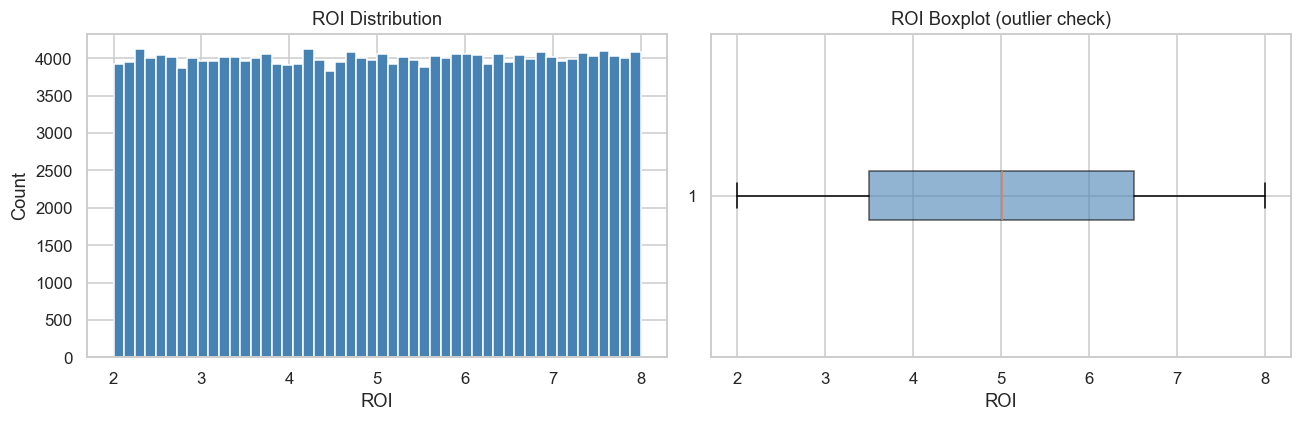

=== ROI Summary Statistics ===
count    200000.00
mean          5.00
std           1.73
min           2.00
25%           3.50
50%           5.01
75%           6.51
max           8.00
Name: ROI, dtype: float64

Skewness: -0.005  (0 = perfect normal, >1 = right skewed)


In [7]:
# CELL 5 — Analyse the target variable: ROI
# WHY: Before modelling, you must understand WHAT you're predicting.
# Is ROI normally distributed? Are there outliers? What's the range?

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram — shows distribution shape
axes[0].hist(df['ROI'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('ROI Distribution')
axes[0].set_xlabel('ROI')
axes[0].set_ylabel('Count')

# Boxplot — shows outliers clearly
axes[1].boxplot(df['ROI'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('ROI Boxplot (outlier check)')
axes[1].set_xlabel('ROI')

plt.tight_layout()
plt.show()

# Summary stats
print("=== ROI Summary Statistics ===")
print(df['ROI'].describe().round(2))
print(f"\nSkewness: {df['ROI'].skew():.3f}  (0 = perfect normal, >1 = right skewed)")

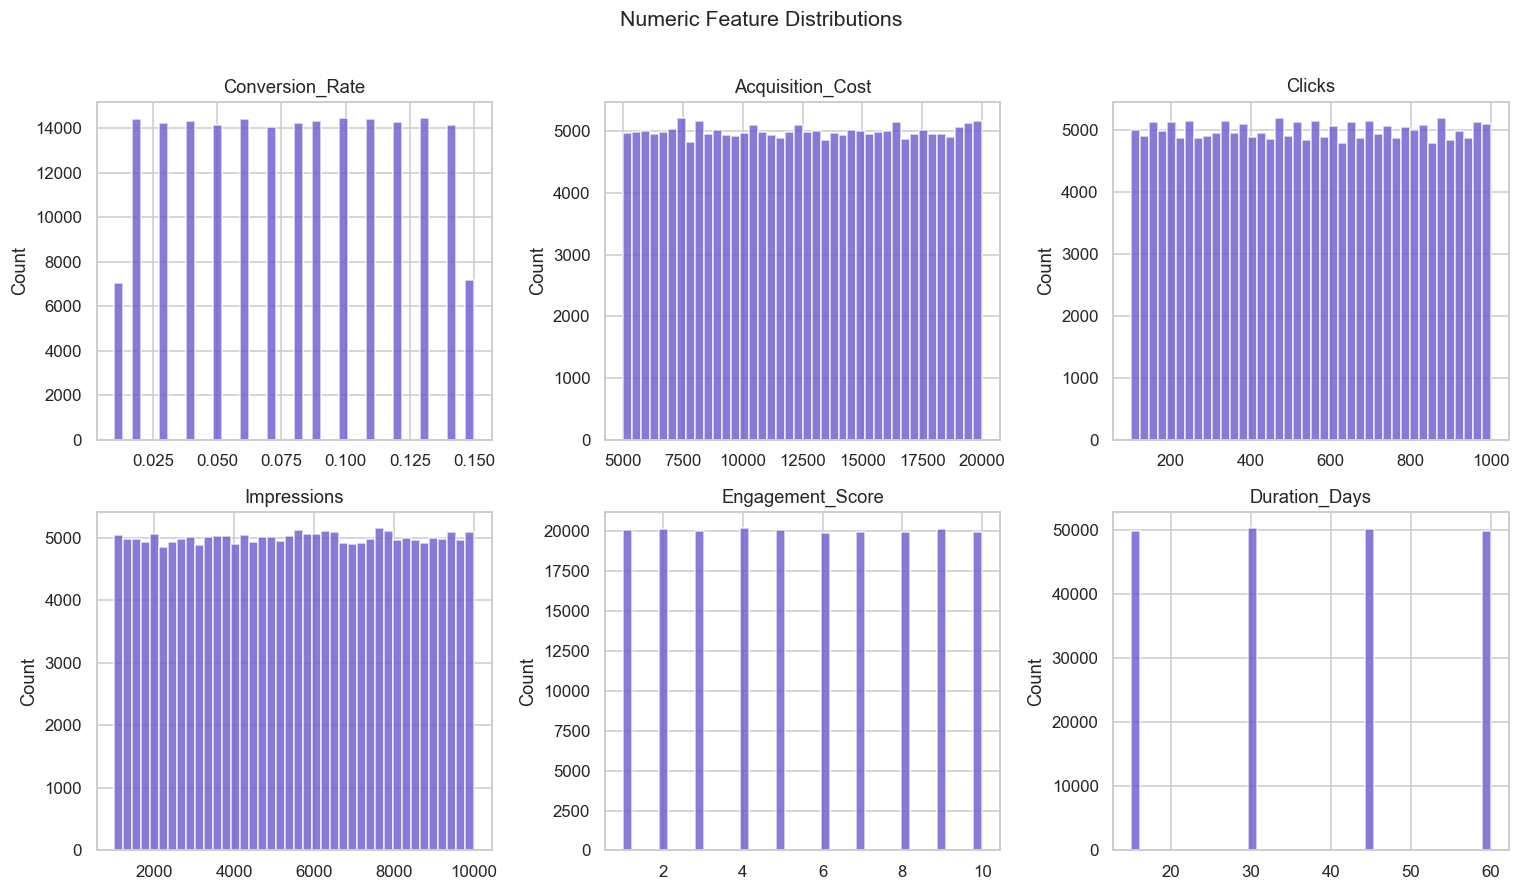

=== Numeric Summary ===
       Conversion_Rate  Acquisition_Cost     Clicks  Impressions  \
count        200000.00         200000.00  200000.00    200000.00   
mean              0.08          12504.39     549.77      5507.30   
std               0.04           4337.66     260.02      2596.86   
min               0.01           5000.00     100.00      1000.00   
25%               0.05           8739.75     325.00      3266.00   
50%               0.08          12496.50     550.00      5517.50   
75%               0.12          16264.00     775.00      7753.00   
max               0.15          20000.00    1000.00     10000.00   

       Engagement_Score  Duration_Days  
count         200000.00      200000.00  
mean               5.49          37.50  
std                2.87          16.75  
min                1.00          15.00  
25%                3.00          30.00  
50%                5.00          30.00  
75%                8.00          45.00  
max               10.00          60

In [8]:
# CELL 6 — Numeric feature distributions
# WHY: You need to know the scale of each feature.
# A feature ranging 0–1 (Conversion_Rate) and one ranging 0–200,000 (Acquisition_Cost)
# will confuse distance-based models unless you scale them later.

numeric_cols = ['Conversion_Rate', 'Acquisition_Cost', 'Clicks',
                'Impressions', 'Engagement_Score', 'Duration_Days']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=40, color='slateblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Numeric Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("=== Numeric Summary ===")
print(df[numeric_cols].describe().round(2))

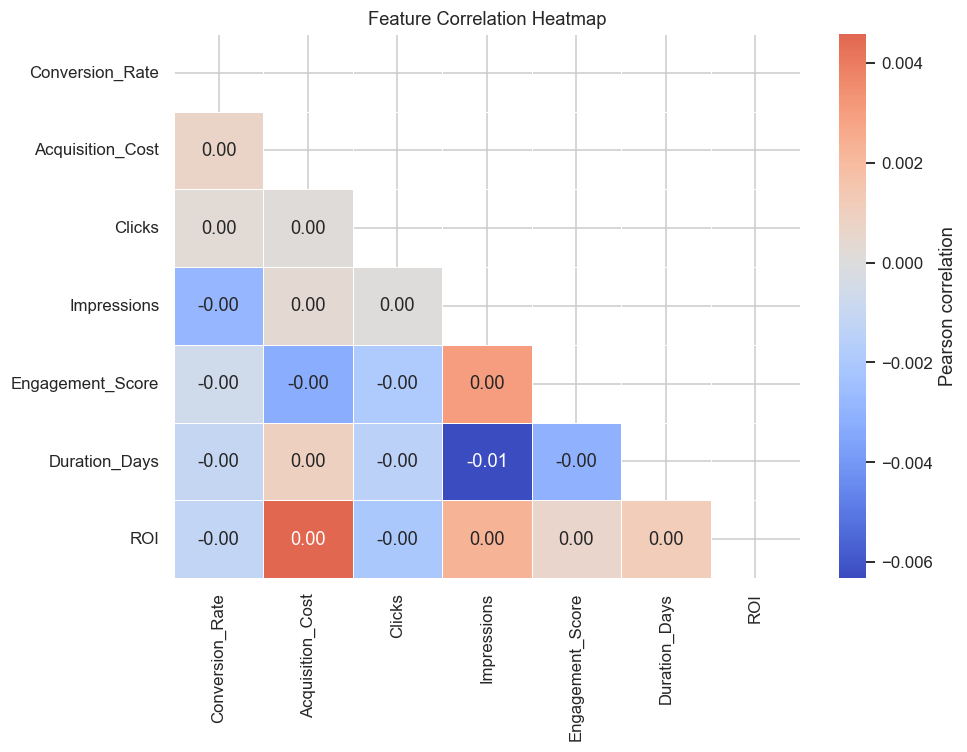


Correlations with ROI (sorted):
Acquisition_Cost    0.005
Impressions         0.002
Duration_Days       0.001
Engagement_Score    0.001
Conversion_Rate    -0.001
Clicks             -0.002
Name: ROI, dtype: float64


In [9]:
# CELL 7 — Correlation heatmap
# WHY: Correlation tells you which features are LINEARLY related to ROI.
# High correlation = likely useful for a linear model.
# Low correlation ≠ useless — tree models can find non-linear relationships.

numeric_df = df[['Conversion_Rate', 'Acquisition_Cost', 'Clicks',
                  'Impressions', 'Engagement_Score', 'Duration_Days', 'ROI']]

corr = numeric_df.corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle (it's a mirror)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            cbar_kws={'label': 'Pearson correlation'})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

print("\nCorrelations with ROI (sorted):")
print(corr['ROI'].drop('ROI').sort_values(ascending=False).round(3))

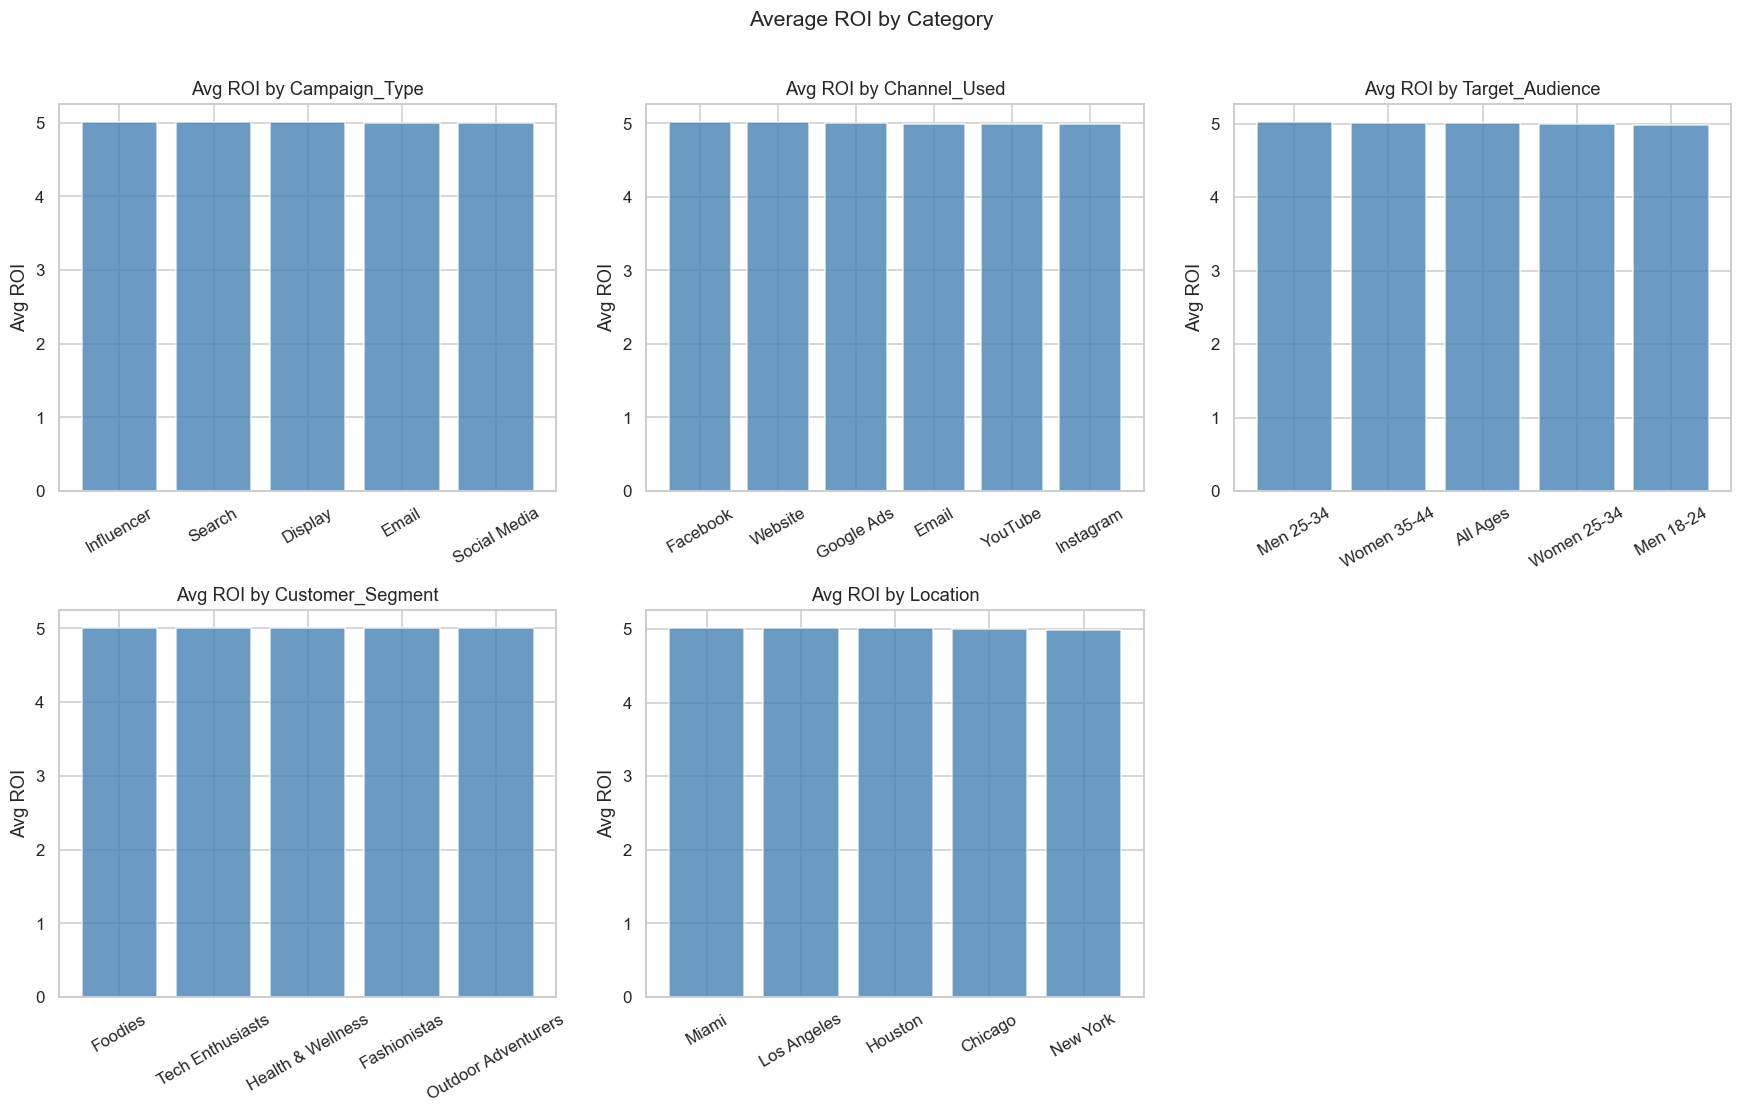


--- Campaign_Type ---
                mean  count
Campaign_Type              
Influencer     5.011  40169
Search         5.008  40157
Display        5.007  39987
Email          4.994  39870
Social Media   4.992  39817

--- Channel_Used ---
               mean  count
Channel_Used              
Facebook      5.019  32819
Website       5.014  33360
Google Ads    5.003  33438
Email         4.996  33599
YouTube       4.994  33392
Instagram     4.989  33392

--- Target_Audience ---
                  mean  count
Target_Audience              
Men 25-34        5.021  40023
Women 35-44      5.006  39687
All Ages         5.005  40019
Women 25-34      4.997  40013
Men 18-24        4.983  40258

--- Customer_Segment ---
                      mean  count
Customer_Segment                 
Foodies              5.004  40208
Tech Enthusiasts     5.004  40151
Health & Wellness    5.003  39888
Fashionistas         5.001  39742
Outdoor Adventurers  4.999  40011

--- Location ---
              mean  count


In [10]:
# CELL 8 — Categorical feature analysis
# WHY: Knowing which Campaign_Type or Channel_Used gets the highest avg ROI
# is CRUCIAL business insight — and will also guide feature encoding later.

cat_cols = ['Campaign_Type', 'Channel_Used', 'Target_Audience',
            'Customer_Segment', 'Location']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    roi_by_cat = df.groupby(col)['ROI'].mean().sort_values(ascending=False)
    axes[i].bar(roi_by_cat.index, roi_by_cat.values, color='steelblue', alpha=0.8)
    axes[i].set_title(f'Avg ROI by {col}')
    axes[i].set_ylabel('Avg ROI')
    axes[i].tick_params(axis='x', rotation=30)

axes[5].axis('off')   # hide empty 6th panel
plt.suptitle('Average ROI by Category', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Print exact numbers too
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df.groupby(col)['ROI'].agg(['mean','count']).round(3).sort_values('mean', ascending=False))

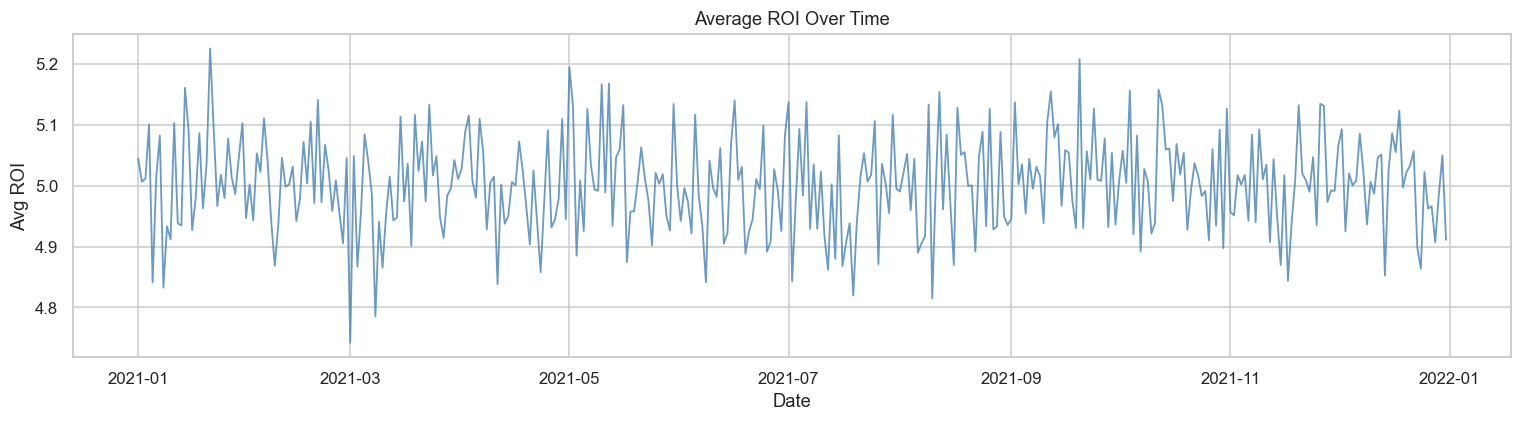

Month value counts:
Month
1     16988
2     15344
3     16988
4     16440
5     16988
6     16440
7     16988
8     16988
9     16440
10    16988
11    16440
12    16968
Name: count, dtype: int64


In [11]:
# CELL 9 — ROI over time
# WHY: If ROI changes seasonally or trends upward/downward,
# that's a valuable signal — and you can extract month/year features from it.

df_time = df.groupby('Date')['ROI'].mean().reset_index()

plt.figure(figsize=(14, 4))
plt.plot(df_time['Date'], df_time['ROI'], color='steelblue', linewidth=1.2, alpha=0.8)
plt.title('Average ROI Over Time')
plt.xlabel('Date')
plt.ylabel('Avg ROI')
plt.tight_layout()
plt.show()

# Extract time features (you'll use these in Phase 2)
df['Month'] = df['Date'].dt.month
df['Year']  = df['Date'].dt.year

print("Month value counts:")
print(df['Month'].value_counts().sort_index())

In [12]:
# CELL 10 — EDA Summary & Sanity Check
# This is your "what did I learn?" cell — every real DS project has one.

print("=" * 55)
print("  EDA COMPLETE — KEY FINDINGS")
print("=" * 55)

print(f"\n Dataset shape      : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f" Missing values     : {df.isnull().sum().sum()}")
print(f" ROI range          : {df['ROI'].min():.2f} → {df['ROI'].max():.2f}")
print(f" ROI mean / std     : {df['ROI'].mean():.2f} / {df['ROI'].std():.2f}")
print(f" ROI skewness       : {df['ROI'].skew():.3f}")

print(f"\n Best avg ROI channel  : {df.groupby('Channel_Used')['ROI'].mean().idxmax()}")
print(f" Best avg ROI campaign : {df.groupby('Campaign_Type')['ROI'].mean().idxmax()}")
print(f" Best avg ROI segment  : {df.groupby('Customer_Segment')['ROI'].mean().idxmax()}")

print(f"\n New features added this phase:")
print(f"   Duration_Days, Month, Year")
print(f"\n Ready for Phase 2: ELT + Feature Engineering ✓")

  EDA COMPLETE — KEY FINDINGS

 Dataset shape      : 200,000 rows × 19 columns
 Missing values     : 0
 ROI range          : 2.00 → 8.00
 ROI mean / std     : 5.00 / 1.73
 ROI skewness       : -0.005

 Best avg ROI channel  : Facebook
 Best avg ROI campaign : Influencer
 Best avg ROI segment  : Foodies

 New features added this phase:
   Duration_Days, Month, Year

 Ready for Phase 2: ELT + Feature Engineering ✓


In [13]:
# CELL 11 — Feature Engineering
# WHY: Raw columns don't always tell the full story.
# CTR (click-through rate) = how engaging was the ad?
# CPC (cost per click)     = how efficient was the spend?
# These derived features are often MORE predictive than raw clicks/cost alone.

# CTR: what % of people who saw the ad actually clicked it
df['CTR'] = df['Clicks'] / df['Impressions']

# CPC: how much did each click cost
df['CPC'] = df['Acquisition_Cost'] / df['Clicks']

# Cost efficiency: ROI per dollar spent (useful for comparisons)
df['Cost_Efficiency'] = df['ROI'] / df['Acquisition_Cost']

# Engagement per impression: normalised engagement
df['Eng_per_Impression'] = df['Engagement_Score'] / df['Impressions']

# Sanity check — make sure no division by zero created inf values
print("Infinite values per column:")
print(df[['CTR','CPC','Cost_Efficiency','Eng_per_Impression']].isin([float('inf'), float('-inf')]).sum())

print("\nNew features sample:")
print(df[['Clicks','Impressions','CTR','Acquisition_Cost','CPC','ROI','Cost_Efficiency']].head())

Infinite values per column:
CTR                   0
CPC                   0
Cost_Efficiency       0
Eng_per_Impression    0
dtype: int64

New features sample:
   Clicks  Impressions       CTR  Acquisition_Cost        CPC   ROI  \
0     506         1922  0.263267           16174.0  31.964427  6.29   
1     116         7523  0.015419           11566.0  99.706897  5.61   
2     584         7698  0.075864           10200.0  17.465753  7.18   
3     217         1820  0.119231           12724.0  58.635945  5.55   
4     379         4201  0.090217           16452.0  43.408971  6.50   

   Cost_Efficiency  
0         0.000389  
1         0.000485  
2         0.000704  
3         0.000436  
4         0.000395  


In [14]:
# CELL 12 — Encode Categorical Columns
# WHY: Models can't read strings like "Facebook" or "Email".
# We convert them to numbers using Label Encoding.
# 
# Two encoding strategies exist:
#   Label Encoding  → assigns each category a number (0,1,2...)
#                     good for tree models (Random Forest, XGBoost)
#   One-Hot Encoding → creates a new column per category (0 or 1)
#                      good for linear models
# We'll use Label Encoding here since we're heading toward tree models.

from sklearn.preprocessing import LabelEncoder

cat_cols = ['Campaign_Type', 'Channel_Used', 'Target_Audience',
            'Customer_Segment', 'Location', 'Language', 'Company']

le = LabelEncoder()
df_model = df.copy()   # IMPORTANT: always work on a copy, never modify df directly

for col in cat_cols:
    df_model[col + '_enc'] = le.fit_transform(df_model[col])
    
print("Encoded columns created:")
for col in cat_cols:
    n_unique = df[col].nunique()
    print(f"  {col:20s} → {col}_enc  ({n_unique} unique categories → numbers 0–{n_unique-1})")

print("\nSample — Campaign_Type vs its encoding:")
print(df_model[['Campaign_Type', 'Campaign_Type_enc']].drop_duplicates().sort_values('Campaign_Type_enc'))

Encoded columns created:
  Campaign_Type        → Campaign_Type_enc  (5 unique categories → numbers 0–4)
  Channel_Used         → Channel_Used_enc  (6 unique categories → numbers 0–5)
  Target_Audience      → Target_Audience_enc  (5 unique categories → numbers 0–4)
  Customer_Segment     → Customer_Segment_enc  (5 unique categories → numbers 0–4)
  Location             → Location_enc  (5 unique categories → numbers 0–4)
  Language             → Language_enc  (5 unique categories → numbers 0–4)
  Company              → Company_enc  (5 unique categories → numbers 0–4)

Sample — Campaign_Type vs its encoding:
  Campaign_Type  Campaign_Type_enc
3       Display                  0
0         Email                  1
2    Influencer                  2
7        Search                  3
8  Social Media                  4


In [15]:
# CELL 13 — Build Final Feature Matrix
# WHY: We now select exactly which columns go into the model.
# This is called defining X (features) and y (target).
# Choosing the RIGHT features is one of the most important DS skills.

# Features we'll use — mix of original numeric + engineered + encoded categorical
feature_cols = [
    # Original numeric
    'Conversion_Rate', 'Acquisition_Cost', 'Clicks',
    'Impressions', 'Engagement_Score', 'Duration_Days',
    # Engineered features
    'CTR', 'CPC', 'Cost_Efficiency', 'Eng_per_Impression',
    'Month', 'Year',
    # Encoded categoricals
    'Campaign_Type_enc', 'Channel_Used_enc', 'Target_Audience_enc',
    'Customer_Segment_enc', 'Location_enc', 'Language_enc', 'Company_enc'
]

X = df_model[feature_cols]
y = df_model['ROI']

print(f"Feature matrix shape : {X.shape}")
print(f"Target shape         : {y.shape}")
print(f"\nFeature columns ({len(feature_cols)} total):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

print(f"\nAny nulls in X? {X.isnull().sum().sum()}")
print(f"Any nulls in y? {y.isnull().sum()}")

Feature matrix shape : (200000, 19)
Target shape         : (200000,)

Feature columns (19 total):
   1. Conversion_Rate
   2. Acquisition_Cost
   3. Clicks
   4. Impressions
   5. Engagement_Score
   6. Duration_Days
   7. CTR
   8. CPC
   9. Cost_Efficiency
  10. Eng_per_Impression
  11. Month
  12. Year
  13. Campaign_Type_enc
  14. Channel_Used_enc
  15. Target_Audience_enc
  16. Customer_Segment_enc
  17. Location_enc
  18. Language_enc
  19. Company_enc

Any nulls in X? 0
Any nulls in y? 0


In [16]:
# CELL 14 — Scale Numeric Features
# WHY: Acquisition_Cost ranges 5k–20k. CTR ranges 0.01–0.99.
# Without scaling, the model pays too much attention to large-scale features.
# StandardScaler transforms each column to mean=0, std=1.
# 
# IMPORTANT RULE: fit the scaler on training data only — never on test data.
# We'll do the train/test split first, then scale.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split: 80% train, 20% test — standard split for this size dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale — fit ONLY on training data, then transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # note: transform only, not fit_transform

print(f"Training set   : {X_train.shape[0]:,} rows")
print(f"Test set       : {X_test.shape[0]:,} rows")
print(f"\nBefore scaling — Acquisition_Cost stats:")
print(f"  mean={X_train['Acquisition_Cost'].mean():.0f}, std={X_train['Acquisition_Cost'].std():.0f}")
print(f"\nAfter scaling — Acquisition_Cost stats:")
scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
print(f"  mean={scaled_df['Acquisition_Cost'].mean():.4f}, std={scaled_df['Acquisition_Cost'].std():.4f}")
print("\n✓ After scaling: mean≈0, std≈1 for every column")

Training set   : 160,000 rows
Test set       : 40,000 rows

Before scaling — Acquisition_Cost stats:
  mean=12503, std=4338

After scaling — Acquisition_Cost stats:
  mean=-0.0000, std=1.0000

✓ After scaling: mean≈0, std≈1 for every column


In [17]:
# CELL 15 — Save cleaned feature dataset
# WHY: We never overwrite the original CSV.
# This new file is what Tableau will use in Phase 6.
# It's also a checkpoint — if your kernel crashes, you don't redo all this work.

# Save the full df_model (with all new features, before scaling)
# Scaling is only for the model — Tableau needs human-readable values
df_model.to_csv('marketing_features.csv', index=False)

print("✓ Saved: marketing_features.csv")
print(f"  Shape  : {df_model.shape}")
print(f"\nColumns saved:")
print(list(df_model.columns))

✓ Saved: marketing_features.csv
  Shape  : (200000, 30)

Columns saved:
['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Language', 'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment', 'Date', 'Duration_Days', 'Month', 'Year', 'CTR', 'CPC', 'Cost_Efficiency', 'Eng_per_Impression', 'Campaign_Type_enc', 'Channel_Used_enc', 'Target_Audience_enc', 'Customer_Segment_enc', 'Location_enc', 'Language_enc', 'Company_enc']


In [18]:
# CELL 16 — Phase 2 Summary
print("=" * 55)
print("  PHASE 2 COMPLETE — ELT + FEATURE ENGINEERING")
print("=" * 55)

print(f"""
 New features created:
   CTR, CPC, Cost_Efficiency, Eng_per_Impression
   Month, Year (from Date)

 Categorical columns encoded:
   {', '.join([c + '_enc' for c in cat_cols])}

 Final feature matrix:
   X shape : {X.shape}
   y shape : {y.shape}

 Train/test split:
   Train : {X_train.shape[0]:,} rows (80%)
   Test  : {X_test.shape[0]:,} rows (20%)

 Saved to: marketing_features.csv

 Ready for Phase 3: LLM Feature Engineering ✓
""")

  PHASE 2 COMPLETE — ELT + FEATURE ENGINEERING

 New features created:
   CTR, CPC, Cost_Efficiency, Eng_per_Impression
   Month, Year (from Date)

 Categorical columns encoded:
   Campaign_Type_enc, Channel_Used_enc, Target_Audience_enc, Customer_Segment_enc, Location_enc, Language_enc, Company_enc

 Final feature matrix:
   X shape : (200000, 19)
   y shape : (200000,)

 Train/test split:
   Train : 160,000 rows (80%)
   Test  : 40,000 rows (20%)

 Saved to: marketing_features.csv

 Ready for Phase 3: LLM Feature Engineering ✓



In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

print("✓ Libraries ready!")

ModuleNotFoundError: No module named 'sentence_transformers'